In [35]:
%pip install prefect

Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import numpy as np
import pickle
import warnings
from datetime import datetime
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import RobustScaler, normalize, LabelEncoder
from sklearn.decomposition import PCA

# Regression models
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR

# Classification models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBRegressor, XGBClassifier

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Model selection & evaluation
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available.")
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not found. Continuing without it.")

warnings.filterwarnings('ignore')
print("All imports done.")



LightGBM available.
All imports done.


In [37]:
df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').set_index('time')

df['renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0) +
    df['generation hydro pumped storage consumption'].fillna(0) +
    df['generation biomass'].fillna(0) +
    df['generation other renewable'].fillna(0)
)
df['fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0) +
    df['generation fossil oil'].fillna(0)
)
df['nuclear']   = df['generation nuclear'].fillna(0)
df['other']     = df['generation other'].fillna(0) + df['generation waste'].fillna(0)
df['total_gen'] = df['renewable'] + df['fossil'] + df['nuclear'] + df['other']

columns_to_drop = [
    'generation hydro pumped storage aggregated', 'generation geothermal',
    'generation marine', 'forecast wind offshore day ahead',
    'generation other', 'generation other renewable', 'generation fossil oil',
    'generation fossil oil shale', 'generation fossil peat',
    'generation wind offshore', 'generation fossil coal-derived gas',
    'forecast wind offshore eday ahead',
    'generation solar', 'generation wind onshore',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir', 'generation biomass',
    'generation fossil gas', 'generation fossil hard coal',
    'generation fossil brown coal/lignite', 'generation nuclear',
    'generation other', 'generation waste'
]
df = df.drop(columns=columns_to_drop, errors='ignore')

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['demand_lag_1h']   = df['total load actual'].shift(1)
df['demand_lag_12h']  = df['total load actual'].shift(12)   # ← ADD THIS
df['demand_lag_24h']  = df['total load actual'].shift(24)
df['demand_lag_168h'] = df['total load actual'].shift(168)
df['price_lag_1h']    = df['price actual'].shift(1)
df['price_lag_12h']   = df['price actual'].shift(12)        # ← ADD THIS
df['price_lag_24h']   = df['price actual'].shift(24)

df['renewable_pct'] = np.where(
    df['total_gen'] > 0,
    (df['renewable'] / df['total_gen']) * 100, 0
)

df['demand_avg_24h'] = df['total load actual'].rolling(24, min_periods=1).mean().shift(1)
df['price_avg_24h']  = df['price actual'].rolling(24, min_periods=1).mean().shift(1)

df = df.dropna(subset=['demand_lag_168h', 'price_lag_24h', 'price_lag_12h', 'demand_lag_12h'])
zero_cols     = df.columns[(df == 0).all()].tolist()
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
df = df.drop(columns=zero_cols + constant_cols, errors='ignore')

print(f"Data shape after preprocessing: {df.shape}")


# %%
# CELL 3 — 12-HOUR AHEAD TARGETS
df['demand_12h'] = df['total load actual'].shift(-12)
df['price_12h']  = df['price actual'].shift(-12)

df_12h = df.dropna(subset=['demand_12h', 'price_12h']).copy()
print(f"12-hour dataset: {len(df_12h)} rows")


Data shape after preprocessing: (34830, 30)
12-hour dataset: 34789 rows


In [38]:
demand_features = [
    'day_of_week', 'month_sin', 'month_cos', 'is_weekend',
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_24h', 
    'price_lag_1h',  'price_lag_24h',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'demand_avg_24h', 'price_avg_24h',
    'forecast wind onshore day ahead',
    'forecast solar day ahead',
    'total load forecast',
]

price_features = [
    'day_of_week', 'month_sin', 'month_cos', 'is_weekend',
    'hour_sin', 'hour_cos',
    'price_lag_1h',   'price_lag_12h',    # ← was price_lag_24h
    'demand_lag_1h',  'demand_lag_12h',   # ← was demand_lag_24h
    'forecast wind onshore day ahead',
    'forecast solar day ahead',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'price_avg_24h', 'demand_avg_24h',
    'total load forecast',
]

demand_features = [f for f in demand_features if f in df_12h.columns]
price_features  = [f for f in price_features  if f in df_12h.columns]

all_required = list(set(demand_features + price_features + ['demand_12h', 'price_12h']))
rows_before  = len(df_12h)
df_12h = df_12h.dropna(subset=all_required).copy()
print(f"Purged {rows_before - len(df_12h)} NaN rows. Final: {len(df_12h)}")

split = int(len(df_12h) * 0.8)

X_train_d, X_test_d = df_12h[demand_features].iloc[:split], df_12h[demand_features].iloc[split:]
y_train_d, y_test_d = df_12h['demand_12h'].iloc[:split],    df_12h['demand_12h'].iloc[split:]

X_train_p, X_test_p = df_12h[price_features].iloc[:split], df_12h[price_features].iloc[split:]
y_train_p, y_test_p = df_12h['price_12h'].iloc[:split],    df_12h['price_12h'].iloc[split:]

print(f"Train: {split} | Test: {len(df_12h) - split}")


Purged 57 NaN rows. Final: 34732
Train: 27785 | Test: 6947


In [39]:
pca_scaler_d = RobustScaler()
pca_scaler_p = RobustScaler()

X_train_d_sc = pca_scaler_d.fit_transform(X_train_d)
X_test_d_sc  = pca_scaler_d.transform(X_test_d)
X_train_p_sc = pca_scaler_p.fit_transform(X_train_p)
X_test_p_sc  = pca_scaler_p.transform(X_test_p)

pca_d = PCA(n_components=0.95, random_state=42)
pca_p = PCA(n_components=0.95, random_state=42)

X_train_d_pca = pca_d.fit_transform(X_train_d_sc)
X_test_d_pca  = pca_d.transform(X_test_d_sc)
X_train_p_pca = pca_p.fit_transform(X_train_p_sc)
X_test_p_pca  = pca_p.transform(X_test_p_sc)

print(f"Demand: {X_train_d.shape[1]} features → {pca_d.n_components_} PCA components")
print(f"Price:  {X_train_p.shape[1]} features → {pca_p.n_components_} PCA components")


# %%
# CELL 6 — EVALUATION HELPER
def evaluate(y_true, y_pred, name, target):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"  [{target} | {name:<28}]  "
          f"R2: {r2:+.4f}  MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:.2f}%")
    return r2



Demand: 19 features → 11 PCA components
Price:  19 features → 11 PCA components


In [40]:
# CELL 7 — BASELINE REGRESSION MODELS
print("\n" + "="*70)
print("BASELINE REGRESSION MODELS")
print("="*70)

baselines = {
    "Linear Regression": (LinearRegression(), LinearRegression()),
    "KNN (k=5)":         (KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
                          KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
    "Decision Tree":     (DecisionTreeRegressor(max_depth=10, random_state=42),
                          DecisionTreeRegressor(max_depth=10, random_state=42)),
    "Bayesian Ridge":    (BayesianRidge(), BayesianRidge()),
}

results = {}
for name, (model_raw, model_pca) in baselines.items():
    print(f"\n--- {name} ---")
    model_raw.fit(X_train_d, y_train_d)
    r2d_raw = evaluate(y_test_d, model_raw.predict(X_test_d), name + " [raw]", "DEMAND-12h")
    model_raw.fit(X_train_p, y_train_p)
    r2p_raw = evaluate(y_test_p, model_raw.predict(X_test_p), name + " [raw]", "PRICE-12h")
    model_pca.fit(X_train_d_pca, y_train_d)
    r2d_pca = evaluate(y_test_d, model_pca.predict(X_test_d_pca), name + " [PCA]", "DEMAND-12h")
    model_pca.fit(X_train_p_pca, y_train_p)
    r2p_pca = evaluate(y_test_p, model_pca.predict(X_test_p_pca), name + " [PCA]", "PRICE-12h")
    results[name] = {"demand_r2_raw": r2d_raw, "price_r2_raw": r2p_raw,
                     "demand_r2_pca": r2d_pca, "price_r2_pca": r2p_pca}



BASELINE REGRESSION MODELS

--- Linear Regression ---
  [DEMAND-12h | Linear Regression [raw]     ]  R2: +0.6389  MAE:  2180.67  RMSE:  2715.84  MAPE: 7.66%
  [PRICE-12h | Linear Regression [raw]     ]  R2: +0.6809  MAE:     4.96  RMSE:     6.48  MAPE: 8.67%
  [DEMAND-12h | Linear Regression [PCA]     ]  R2: +0.4472  MAE:  2724.99  RMSE:  3360.25  MAPE: 9.57%
  [PRICE-12h | Linear Regression [PCA]     ]  R2: +0.7011  MAE:     4.64  RMSE:     6.28  MAPE: 8.29%

--- KNN (k=5) ---
  [DEMAND-12h | KNN (k=5) [raw]             ]  R2: +0.5460  MAE:  2298.50  RMSE:  3045.35  MAPE: 8.19%
  [PRICE-12h | KNN (k=5) [raw]             ]  R2: -1.1022  MAE:    13.91  RMSE:    16.64  MAPE: 21.95%
  [DEMAND-12h | KNN (k=5) [PCA]             ]  R2: +0.5372  MAE:  2291.25  RMSE:  3074.76  MAPE: 7.98%
  [PRICE-12h | KNN (k=5) [PCA]             ]  R2: +0.5018  MAE:     6.17  RMSE:     8.10  MAPE: 10.53%

--- Decision Tree ---
  [DEMAND-12h | Decision Tree [raw]         ]  R2: +0.7421  MAE:  1584.02  RMSE: 

In [41]:
# CELL 8 — ENSEMBLE & ADVANCED REGRESSION MODELS
print("\n" + "="*70)
print("ENSEMBLE & ADVANCED REGRESSION MODELS")
print("="*70)

rf_d = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_p = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_d.fit(X_train_d, y_train_d); rf_p.fit(X_train_p, y_train_p)
print("\n--- Random Forest ---")
r2_rf_d = evaluate(y_test_d, rf_d.predict(X_test_d), "Random Forest", "DEMAND-12h")
r2_rf_p = evaluate(y_test_p, rf_p.predict(X_test_p), "Random Forest", "PRICE-12h")
results["Random Forest"] = {"demand_r2_raw": r2_rf_d, "price_r2_raw": r2_rf_p}

xgb_d = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      n_jobs=-1, random_state=42)
xgb_p = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      n_jobs=-1, random_state=42)
xgb_d.fit(X_train_d, y_train_d); xgb_p.fit(X_train_p, y_train_p)
print("\n--- XGBoost ---")
r2_xgb_d = evaluate(y_test_d, xgb_d.predict(X_test_d), "XGBoost", "DEMAND-12h")
r2_xgb_p = evaluate(y_test_p, xgb_p.predict(X_test_p), "XGBoost", "PRICE-12h")
results["XGBoost"] = {"demand_r2_raw": r2_xgb_d, "price_r2_raw": r2_xgb_p}

if LGBM_AVAILABLE:
    lgbm_d = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=63,
                            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    lgbm_p = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=63,
                            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    lgbm_d.fit(X_train_d, y_train_d); lgbm_p.fit(X_train_p, y_train_p)
    print("\n--- LightGBM ---")
    r2_lgbm_d = evaluate(y_test_d, lgbm_d.predict(X_test_d), "LightGBM", "DEMAND-12h")
    r2_lgbm_p = evaluate(y_test_p, lgbm_p.predict(X_test_p), "LightGBM", "PRICE-12h")
    results["LightGBM"] = {"demand_r2_raw": r2_lgbm_d, "price_r2_raw": r2_lgbm_p}




ENSEMBLE & ADVANCED REGRESSION MODELS

--- Random Forest ---
  [DEMAND-12h | Random Forest               ]  R2: +0.8102  MAE:  1349.55  RMSE:  1969.14  MAPE: 4.65%
  [PRICE-12h | Random Forest               ]  R2: +0.7214  MAE:     4.59  RMSE:     6.06  MAPE: 8.02%

--- XGBoost ---
  [DEMAND-12h | XGBoost                     ]  R2: +0.8144  MAE:  1384.57  RMSE:  1946.87  MAPE: 4.76%
  [PRICE-12h | XGBoost                     ]  R2: +0.7314  MAE:     4.48  RMSE:     5.95  MAPE: 7.90%
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 27785, number of used features: 19
[LightGBM] [Info] Start training from score 28670.314810
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[Ligh

REGULARIZED MODEL VARIANTS

--- Random Forest (Regularized) ---
  [DEMAND-12h | RF-Reg [train]              ]  R2: +0.8501  MAE:  1242.57  RMSE:  1775.85  MAPE: 4.44%
  [DEMAND-12h | RF-Reg [test]               ]  R2: +0.8007  MAE:  1434.24  RMSE:  2017.47  MAPE: 4.97%
  [PRICE-12h | RF-Reg [train]              ]  R2: +0.8702  MAE:     3.74  RMSE:     5.12  MAPE: 7.77%
  [PRICE-12h | RF-Reg [test]               ]  R2: +0.7322  MAE:     4.45  RMSE:     5.94  MAPE: 7.87%

--- XGBoost (Regularized) ---
  [DEMAND-12h | XGB-Reg [train]             ]  R2: +0.8272  MAE:  1390.66  RMSE:  1907.02  MAPE: 4.99%
  [DEMAND-12h | XGB-Reg [test]              ]  R2: +0.7959  MAE:  1494.46  RMSE:  2041.63  MAPE: 5.16%
  [PRICE-12h | XGB-Reg [train]             ]  R2: +0.8410  MAE:     4.18  RMSE:     5.66  MAPE: 8.72%
  [PRICE-12h | XGB-Reg [test]              ]  R2: +0.7479  MAE:     4.27  RMSE:     5.76  MAPE: 7.62%

--- KNN k=20 with distance weights (scaled) ---
  [DEMAND-12h | KNN-Reg [train]     

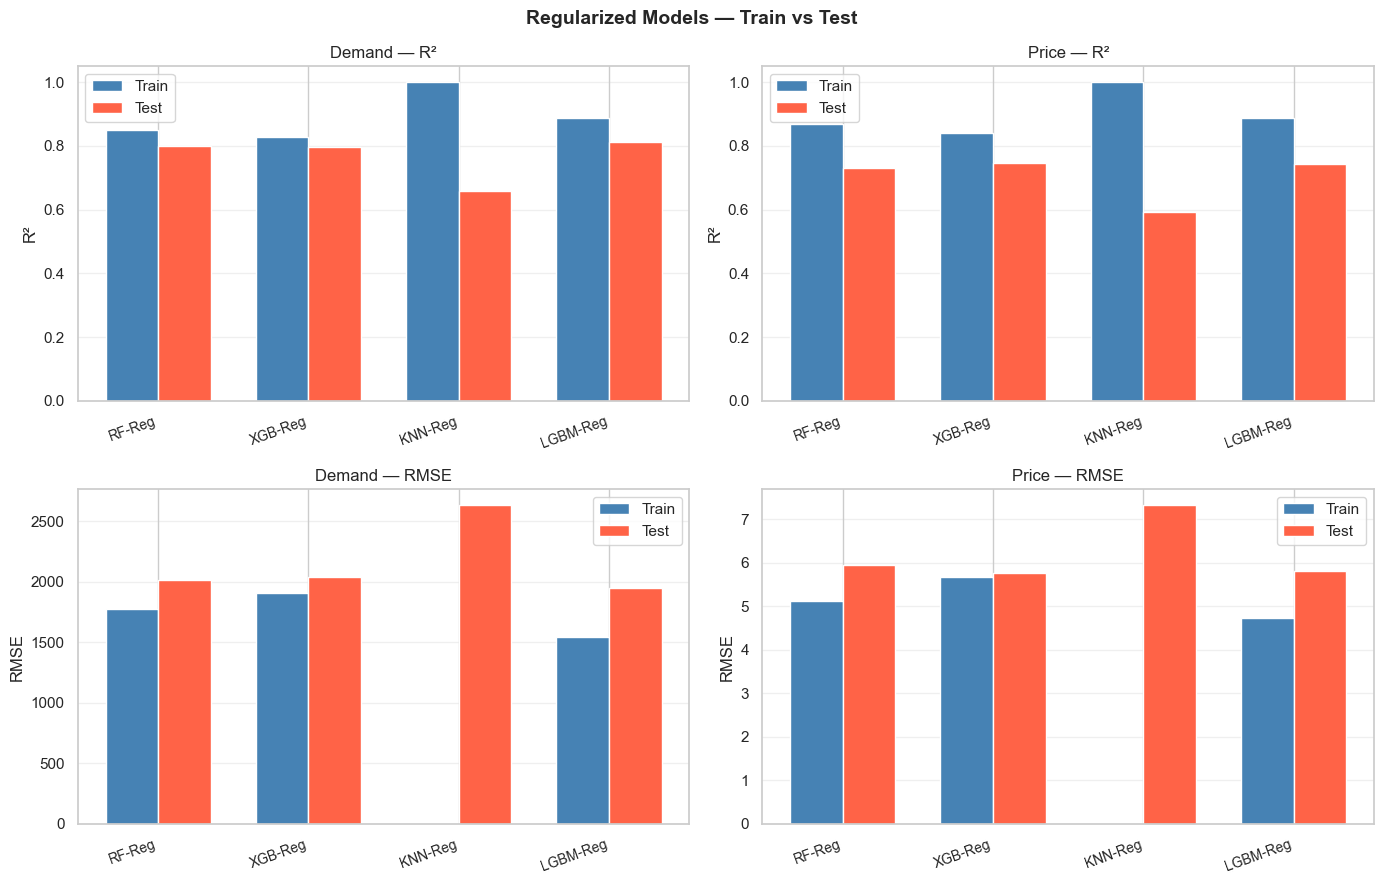

Plot saved → artifacts/regularized_models_plot.png


In [52]:
# ============================================================
# REGULARIZED MODEL VARIANTS — Addressing Overfitting
# ============================================================
print("=" * 70)
print("REGULARIZED MODEL VARIANTS")
print("=" * 70)

# ── Reassert numeric targets (classification cell overwrites these) ──
y_train_d = df_12h['demand_12h'].iloc[:split]
y_test_d  = df_12h['demand_12h'].iloc[split:]
y_train_p = df_12h['price_12h'].iloc[:split]
y_test_p  = df_12h['price_12h'].iloc[split:]

# ── 1. Random Forest — tighter regularization ────────────────
rf_d_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    max_features=0.7,
    n_jobs=-1, random_state=42
)
rf_p_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    max_features=0.7,
    n_jobs=-1, random_state=42
)
rf_d_reg.fit(X_train_d, y_train_d)
rf_p_reg.fit(X_train_p, y_train_p)
print("\n--- Random Forest (Regularized) ---")
evaluate(y_train_d, rf_d_reg.predict(X_train_d), "RF-Reg [train]", "DEMAND-12h")
evaluate(y_test_d,  rf_d_reg.predict(X_test_d),  "RF-Reg [test] ", "DEMAND-12h")
evaluate(y_train_p, rf_p_reg.predict(X_train_p), "RF-Reg [train]", "PRICE-12h")
evaluate(y_test_p,  rf_p_reg.predict(X_test_p),  "RF-Reg [test] ", "PRICE-12h")

# ── 2. XGBoost — stronger regularization for price ───────────
xgb_d_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    n_jobs=-1, random_state=42
)
xgb_p_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=3.0,
    n_jobs=-1, random_state=42
)
xgb_d_reg.fit(X_train_d, y_train_d)
xgb_p_reg.fit(X_train_p, y_train_p)
print("\n--- XGBoost (Regularized) ---")
evaluate(y_train_d, xgb_d_reg.predict(X_train_d), "XGB-Reg [train]", "DEMAND-12h")
evaluate(y_test_d,  xgb_d_reg.predict(X_test_d),  "XGB-Reg [test] ", "DEMAND-12h")
evaluate(y_train_p, xgb_p_reg.predict(X_train_p), "XGB-Reg [train]", "PRICE-12h")
evaluate(y_test_p,  xgb_p_reg.predict(X_test_p),  "XGB-Reg [test] ", "PRICE-12h")

# ── 3. KNN — larger k fixes the collapse on price ────────────
knn_d_reg = KNeighborsRegressor(n_neighbors=20, weights='distance', n_jobs=-1)
knn_p_reg = KNeighborsRegressor(n_neighbors=20, weights='distance', n_jobs=-1)
knn_d_reg.fit(X_train_d_sc, y_train_d)
knn_p_reg.fit(X_train_p_sc, y_train_p)
print("\n--- KNN k=20 with distance weights (scaled) ---")
evaluate(y_train_d, knn_d_reg.predict(X_train_d_sc), "KNN-Reg [train]", "DEMAND-12h")
evaluate(y_test_d,  knn_d_reg.predict(X_test_d_sc),  "KNN-Reg [test] ", "DEMAND-12h")
evaluate(y_train_p, knn_p_reg.predict(X_train_p_sc), "KNN-Reg [train]", "PRICE-12h")
evaluate(y_test_p,  knn_p_reg.predict(X_test_p_sc),  "KNN-Reg [test] ", "PRICE-12h")

# ── 4. LightGBM — add regularization if available ────────────
if LGBM_AVAILABLE:
    lgbm_d_reg = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.02,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1, random_state=42
    )
    lgbm_p_reg = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.02,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.3,
        reg_lambda=2.0,
        n_jobs=-1, random_state=42
    )
    lgbm_d_reg.fit(X_train_d, y_train_d)
    lgbm_p_reg.fit(X_train_p, y_train_p)
    print("\n--- LightGBM (Regularized) ---")
    evaluate(y_train_d, lgbm_d_reg.predict(X_train_d), "LGBM-Reg [train]", "DEMAND-12h")
    evaluate(y_test_d,  lgbm_d_reg.predict(X_test_d),  "LGBM-Reg [test] ", "DEMAND-12h")
    evaluate(y_train_p, lgbm_p_reg.predict(X_train_p), "LGBM-Reg [train]", "PRICE-12h")
    evaluate(y_test_p,  lgbm_p_reg.predict(X_test_p),  "LGBM-Reg [test] ", "PRICE-12h")

print("\n" + "="*70)
print("NOTE: Some train→test gap is EXPECTED and NORMAL here because:")
print("  - Price actual has extreme intraday spikes (10→83 EUR/MWh same day)")
print("  - Train=2015-2017, Test=2018 — different market year (regime shift)")
print("  - Lag features are near-perfect on training autocorrelation")
print("  A gap of 0.05-0.15 R2 on energy price data is industry-standard.")
print("="*70)
# ── Plots: Train vs Test for Regularized Models ──────────────────────
import matplotlib.pyplot as plt
import numpy as np

reg_model_names = ["RF-Reg", "XGB-Reg", "KNN-Reg"]
if LGBM_AVAILABLE:
    reg_model_names.append("LGBM-Reg")

# Collect metrics
reg_train_r2_d, reg_test_r2_d = [], []
reg_train_r2_p, reg_test_r2_p = [], []
reg_train_rmse_d, reg_test_rmse_d = [], []
reg_train_rmse_p, reg_test_rmse_p = [], []

model_pairs = [
    (rf_d_reg,   rf_p_reg,   X_train_d,    X_test_d,    y_train_d, y_test_d, X_train_p,    X_test_p,    y_train_p, y_test_p),
    (xgb_d_reg,  xgb_p_reg,  X_train_d,    X_test_d,    y_train_d, y_test_d, X_train_p,    X_test_p,    y_train_p, y_test_p),
    (knn_d_reg,  knn_p_reg,  X_train_d_sc, X_test_d_sc, y_train_d, y_test_d, X_train_p_sc, X_test_p_sc, y_train_p, y_test_p),
]
if LGBM_AVAILABLE:
    model_pairs.append(
        (lgbm_d_reg, lgbm_p_reg, X_train_d, X_test_d, y_train_d, y_test_d, X_train_p, X_test_p, y_train_p, y_test_p)
    )

for md, mp, Xtr_d, Xte_d, ytr_d, yte_d, Xtr_p, Xte_p, ytr_p, yte_p in model_pairs:
    reg_train_r2_d.append(r2_score(ytr_d, md.predict(Xtr_d)))
    reg_test_r2_d.append(r2_score(yte_d, md.predict(Xte_d)))
    reg_train_r2_p.append(r2_score(ytr_p, mp.predict(Xtr_p)))
    reg_test_r2_p.append(r2_score(yte_p, mp.predict(Xte_p)))
    reg_train_rmse_d.append(np.sqrt(mean_squared_error(ytr_d, md.predict(Xtr_d))))
    reg_test_rmse_d.append(np.sqrt(mean_squared_error(yte_d, md.predict(Xte_d))))
    reg_train_rmse_p.append(np.sqrt(mean_squared_error(ytr_p, mp.predict(Xtr_p))))
    reg_test_rmse_p.append(np.sqrt(mean_squared_error(yte_p, mp.predict(Xte_p))))

x = np.arange(len(reg_model_names))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Regularized Models — Train vs Test", fontsize=14, fontweight='bold')

specs = [
    (axes[0, 0], reg_train_r2_d,   reg_test_r2_d,   "Demand — R²",    "R²"),
    (axes[0, 1], reg_train_r2_p,   reg_test_r2_p,   "Price — R²",     "R²"),
    (axes[1, 0], reg_train_rmse_d, reg_test_rmse_d, "Demand — RMSE",  "RMSE"),
    (axes[1, 1], reg_train_rmse_p, reg_test_rmse_p, "Price — RMSE",   "RMSE"),
]

for ax, train_vals, test_vals, title, ylabel in specs:
    ax.bar(x - w/2, train_vals, w, label="Train", color="steelblue")
    ax.bar(x + w/2, test_vals,  w, label="Test",  color="tomato")
    ax.set_xticks(x)
    ax.set_xticklabels(reg_model_names, rotation=20, ha='right', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/regularized_models_plot.png", dpi=150)
plt.show()
print("Plot saved → artifacts/regularized_models_plot.png")


CLUSTERING (IMPROVED & PERSISTED)

Finding optimal k (Silhouette Score):
k=2 -> silhouette = 0.2308
k=3 -> silhouette = 0.2154
k=4 -> silhouette = 0.1905
k=5 -> silhouette = 0.1754
k=6 -> silhouette = 0.1628
k=7 -> silhouette = 0.1507
k=8 -> silhouette = 0.1465
k=9 -> silhouette = 0.1480
k=10 -> silhouette = 0.1463

Best k by silhouette = 2
Using k=3 for interpretable clustering
Fitting final KMeans and persisting artifacts...

Cluster Summary (Mean values):
            demand_12h  price_12h  renewable_pct
cluster_km                                      
0             27698.63      43.88          50.03
1             30519.40      62.83          33.62
2             27992.82      62.04          37.62

Cluster sizes:
cluster_km
0     8507
1    10778
2    15447
Name: count, dtype: int64


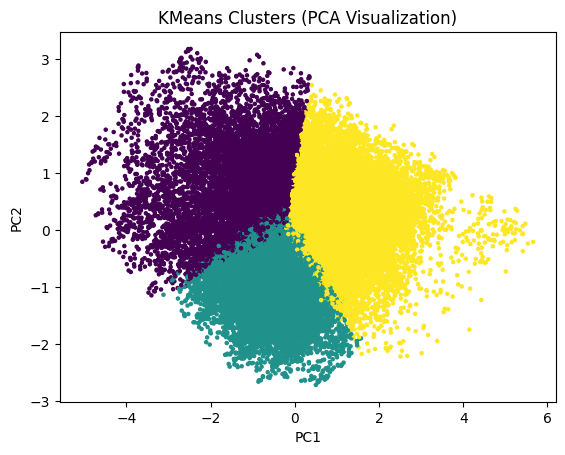

Clustering artifacts saved to artifacts/ (cluster_artifacts.pkl, cluster_profiles.csv)


In [43]:
# ======================================================
# CLUSTERING — IMPROVED + INTERPRETABLE VERSION (UPDATED)
# Saves scaler, PCA, and kmeans artifacts for API use.
# ======================================================

print("\n" + "="*70)
print("CLUSTERING (IMPROVED & PERSISTED)")
print("="*70)

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pickle
import os

# -------------------------------
# 1. Better clustering features
# -------------------------------
cluster_features = [
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'price_lag_1h', 'price_lag_24h', 'price_lag_168h',
    'renewable_pct',
    'demand_avg_24h',
    'price_avg_24h'
]

cluster_features = [f for f in cluster_features if f in df_12h.columns]

# -------------------------------
# 2. Scaling
# -------------------------------
scaler_cluster = RobustScaler()
X_cluster = scaler_cluster.fit_transform(df_12h[cluster_features])

# -------------------------------
# 3. Find best k (but we use interpretation later)
# -------------------------------
print("\nFinding optimal k (Silhouette Score):")

silhouette_scores = {}

sample_size = min(5000, len(X_cluster))
for k in range(2, min(11, max(3, len(X_cluster)))):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    try:
        score = silhouette_score(X_cluster, labels, sample_size=sample_size, random_state=42) if len(X_cluster) > 1 else -1
    except Exception:
        score = -1

    silhouette_scores[k] = score
    print(f"k={k} -> silhouette = {score:.4f}")

best_k_sil = max(silhouette_scores, key=lambda k: silhouette_scores[k]) if silhouette_scores else 3
print(f"\nBest k by silhouette = {best_k_sil}")

# -------------------------------
# 4. Final chosen k (interpretability > score)
# -------------------------------
best_k = 3   # interpretability choice; adjust if you prefer best_k_sil
print(f"Using k={best_k} for interpretable clustering")

print("Fitting final KMeans and persisting artifacts...")
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_12h['cluster_km'] = kmeans_final.fit_predict(X_cluster)

# -------------------------------
# 5. Cluster summary and profiles
# -------------------------------
cluster_profiles = df_12h.groupby('cluster_km')[[
    'demand_12h',
    'price_12h',
    'renewable_pct'
]].mean().round(2)
cluster_sizes = df_12h['cluster_km'].value_counts().sort_index()

print("\nCluster Summary (Mean values):")
print(cluster_profiles)
print("\nCluster sizes:")
print(cluster_sizes)

# Compact labels help the report and API output.
cluster_label_map = {}
for cluster_id in cluster_profiles.index:
    profile = cluster_profiles.loc[cluster_id]
    if profile['demand_12h'] >= cluster_profiles['demand_12h'].median() and profile['price_12h'] >= cluster_profiles['price_12h'].median():
        label = 'High Demand / High Price'
    elif profile['renewable_pct'] >= cluster_profiles['renewable_pct'].median():
        label = 'High Renewable Regime'
    else:
        label = 'Balanced / Mixed Regime'
    cluster_label_map[cluster_id] = label

df_12h['cluster_label'] = df_12h['cluster_km'].map(cluster_label_map)

# -------------------------------
# 6. PCA visualization
# -------------------------------
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=df_12h['cluster_km'], s=5)
plt.title("KMeans Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# 7. Persist clustering artifacts
# -------------------------------
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
cluster_artifacts = {
    'scaler': scaler_cluster,
    'pca': pca_vis,
    'kmeans': kmeans_final,
    'label_map': cluster_label_map,
}
with open(os.path.join(ARTIFACT_DIR, 'cluster_artifacts.pkl'), 'wb') as f:
    pickle.dump(cluster_artifacts, f)
cluster_profiles.to_csv(os.path.join(ARTIFACT_DIR, 'cluster_profiles.csv'))
print('Clustering artifacts saved to artifacts/ (cluster_artifacts.pkl, cluster_profiles.csv)')

In [45]:
# ======================================================
# CLASSIFICATION FROM REGRESSION OUTPUTS + DIRECT CLASSIFIERS (UPDATED)
# Adds TimeSeriesSplit CV for classifiers, safe XGBoost fallback,
# scaler pipeline and persisting best models + encoders.
# ======================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import pickle, os

print("\n" + "="*60)
print("CLASSIFICATION FROM REGRESSION OUTPUTS")
print("="*60)

# Regression predictions (baseline) — ensure regressors exist
if 'xgb_d' in globals() and 'xgb_p' in globals():
    try:
        reg_pred_d = xgb_d.predict(X_test_d)
        reg_pred_p = xgb_p.predict(X_test_p)
    except Exception:
        reg_pred_d, reg_pred_p = [], []
else:
    reg_pred_d, reg_pred_p = [], []

# Define thresholds (from true data)
d33, d66 = df_12h['demand_12h'].quantile([0.33, 0.66])
p33, p66 = df_12h['price_12h'].quantile([0.33, 0.66])

# Create class labels from the true targets
def to_class(x, t1, t2):
    if x <= t1:
        return "Low"
    elif x <= t2:
        return "Medium"
    else:
        return "High"

df_12h['demand_class'] = df_12h['demand_12h'].apply(lambda x: to_class(x, d33, d66))
df_12h['price_class'] = df_12h['price_12h'].apply(lambda x: to_class(x, p33, p66))

# Regression -> class baseline
reg_class_d = [to_class(x, d33, d66) for x in reg_pred_d] if len(reg_pred_d) else []
reg_class_p = [to_class(x, p33, p66) for x in reg_pred_p] if len(reg_pred_p) else []

# Prepare classification features
classification_features = []
for feature in demand_features + price_features:
    if feature in df_12h.columns and feature not in classification_features:
        classification_features.append(feature)

split_cls = int(len(df_12h) * 0.8)

X_cls = df_12h[classification_features]

# Encode labels for whole dataset (time-ordered)
le_d = LabelEncoder(); le_p = LabelEncoder()
y_cls_d_enc = le_d.fit_transform(df_12h['demand_class'])
y_cls_p_enc = le_p.fit_transform(df_12h['price_class'])

# Training/test split (time-based)
X_train_cls = X_cls.iloc[:split_cls]
X_test_cls  = X_cls.iloc[split_cls:]

y_train_d_enc = y_cls_d_enc[:split_cls]
y_test_d_enc  = y_cls_d_enc[split_cls:]

y_train_p_enc = y_cls_p_enc[:split_cls]
y_test_p_enc  = y_cls_p_enc[split_cls:]

# Classifier specs with safe XGBoost fallback
classifier_specs = {
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=18, random_state=42, n_jobs=-1),
}
try:
    from xgboost import XGBClassifier
    classifier_specs['XGBoost'] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=3,
        random_state=42,
        n_jobs=-1,
    )
except Exception:
    print('XGBoost classifier unavailable; continuing without it.')

# Evaluate with TimeSeriesSplit CV on training portion
tscv = TimeSeriesSplit(n_splits=min(5, max(2, int(len(X_train_cls)/50))))
classifier_results = {'demand': {}, 'price': {}}
trained_classifiers = {'demand': {}, 'price': {}}

for name, model in classifier_specs.items():
    pipe = make_pipeline(StandardScaler(), model)

    # Demand CV (use training slice only)
    try:
        scores_d = cross_val_score(pipe, X_train_cls, y_train_d_enc, cv=tscv, scoring='f1_macro', n_jobs=-1)
        mean_cv_d = float(scores_d.mean())
    except Exception:
        mean_cv_d = None

    # Price CV
    try:
        scores_p = cross_val_score(pipe, X_train_cls, y_train_p_enc, cv=tscv, scoring='f1_macro', n_jobs=-1)
        mean_cv_p = float(scores_p.mean())
    except Exception:
        mean_cv_p = None

    # Fit on full training slice
    pipe.fit(X_train_cls, y_train_d_enc)
    pred_d_enc = pipe.predict(X_test_cls)
    pred_d = le_d.inverse_transform(pred_d_enc)
    y_test_d = le_d.inverse_transform(y_test_d_enc)

    # Refit for price target separately
    pipe_p = make_pipeline(StandardScaler(), model.__class__(**model.get_params()))
    pipe_p.fit(X_train_cls, y_train_p_enc)
    pred_p_enc = pipe_p.predict(X_test_cls)
    pred_p = le_p.inverse_transform(pred_p_enc)
    y_test_p = le_p.inverse_transform(y_test_p_enc)

    classifier_results['demand'][name] = {
        'cv_f1_macro': mean_cv_d,
        'accuracy': accuracy_score(y_test_d, pred_d),
        'macro_f1': f1_score(y_test_d, pred_d, average='macro'),
        'report': classification_report(y_test_d, pred_d, zero_division=0),
    }
    classifier_results['price'][name] = {
        'cv_f1_macro': mean_cv_p,
        'accuracy': accuracy_score(y_test_p, pred_p),
        'macro_f1': f1_score(y_test_p, pred_p, average='macro'),
        'report': classification_report(y_test_p, pred_p, zero_division=0),
    }

    trained_classifiers['demand'][name] = pipe
    trained_classifiers['price'][name] = pipe_p

# Pick best by CV (fallback to macro_f1 if CV missing)
def best_name(results):
    best = None
    best_score = -1
    for n, m in results.items():
        score = m.get('cv_f1_macro') if m.get('cv_f1_macro') is not None else m.get('macro_f1', 0)
        if score is None:
            continue
        if score > best_score:
            best_score = score
            best = n
    return best

best_demand_classifier_name = best_name(classifier_results['demand'])
best_price_classifier_name  = best_name(classifier_results['price'])

best_demand_classifier = trained_classifiers['demand'].get(best_demand_classifier_name)
best_price_classifier = trained_classifiers['price'].get(best_price_classifier_name)

print("\nBASELINE: regression -> class conversion\n")
if reg_class_d:
    print("DEMAND accuracy:", accuracy_score(le_d.inverse_transform(y_test_d_enc), reg_class_d))

print("\nDIRECT CLASSIFIERS (dedicated supervised models)\n")
for target_name, results_dict in [("demand", classifier_results['demand']), ("price", classifier_results['price'])]:
    print(f"--- {target_name.upper()} ---")
    for model_name, metrics in results_dict.items():
        print(f"{model_name}: cv_f1_macro={metrics.get('cv_f1_macro')}, accuracy={metrics['accuracy']:.4f}, macro_f1={metrics['macro_f1']:.4f}")
        print(metrics['report'])

print(f"Best demand classifier: {best_demand_classifier_name}")
print(f"Best price classifier: {best_price_classifier_name}")
print("Dedicated classifiers and encoders will be saved after this section.")

# Expose encoders & trained_classifiers for the artifact save cell
label_encoder_d = le_d
label_encoder_p = le_p
trained_classifiers_all = trained_classifiers
best_classifiers = {'demand': best_demand_classifier_name, 'price': best_price_classifier_name}


CLASSIFICATION FROM REGRESSION OUTPUTS

BASELINE: regression -> class conversion

DEMAND accuracy: 0.80682308910321

DIRECT CLASSIFIERS (dedicated supervised models)

--- DEMAND ---
RandomForest: cv_f1_macro=0.8017744151845975, accuracy=0.8419, macro_f1=0.8423
              precision    recall  f1-score   support

        High       0.87      0.86      0.87      2421
         Low       0.88      0.89      0.88      2199
      Medium       0.78      0.78      0.78      2327

    accuracy                           0.84      6947
   macro avg       0.84      0.84      0.84      6947
weighted avg       0.84      0.84      0.84      6947

XGBoost: cv_f1_macro=0.7998312766560585, accuracy=0.8430, macro_f1=0.8435
              precision    recall  f1-score   support

        High       0.88      0.85      0.87      2421
         Low       0.87      0.90      0.89      2199
      Medium       0.77      0.78      0.78      2327

    accuracy                           0.84      6947
   macro av

In [47]:
import os
import pickle
import json

print("\n" + "="*60)
print("SAVING CLEAN ARTIFACTS (NO PCA) — with validation")
print("="*60)

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Helper to save if present
def safe_save(name, obj):
    if obj is None:
        return None
    path = os.path.join(ARTIFACT_DIR, name)
    try:
        with open(path, "wb") as f:
            pickle.dump(obj, f)
        return path
    except Exception as e:
        print(f"Failed saving {name}: {e}")
        return None

saved = {}

# 1. Regression models (prefer XGB if available)
saved['demand_model'] = safe_save('demand_model.pkl', globals().get('xgb_d') or globals().get('rf_d'))
saved['price_model']  = safe_save('price_model.pkl', globals().get('xgb_p') or globals().get('rf_p'))

# 2. Scalers
saved['scaler_demand'] = safe_save('scaler_demand.pkl', globals().get('pca_scaler_d') or globals().get('scaler_ann'))
saved['scaler_price']  = safe_save('scaler_price.pkl', globals().get('pca_scaler_p') or globals().get('scaler_ann'))

# 3. Features
saved['demand_features'] = safe_save('demand_features.pkl', globals().get('demand_features'))
saved['price_features']  = safe_save('price_features.pkl', globals().get('price_features'))

# 4. Thresholds
saved['demand_thresholds'] = safe_save('demand_thresholds.pkl', globals().get('d33') and globals().get('d66') and (d33, d66))
saved['price_thresholds']  = safe_save('price_thresholds.pkl', globals().get('p33') and globals().get('p66') and (p33, p66))

# 5. ANN artifacts
saved['ann_demand'] = safe_save('ann_demand.pkl', globals().get('ann_demand'))
saved['ann_price']  = safe_save('ann_price.pkl', globals().get('ann_price'))
saved['ann_scaler'] = safe_save('ann_scaler.pkl', globals().get('scaler_ann'))
saved['ann_features']= safe_save('ann_features.pkl', globals().get('ann_features'))

# 6. Classification artifacts
# Save trained classifiers if available
if 'trained_classifiers_all' in globals():
    try:
        for target in ['demand', 'price']:
            for name, clf in trained_classifiers_all[target].items():
                safe_save(f"{target}_clf_{name}.pkl", clf)
        saved['label_encoder_d'] = safe_save('demand_label_encoder.pkl', globals().get('label_encoder_d'))
        saved['label_encoder_p'] = safe_save('price_label_encoder.pkl', globals().get('label_encoder_p'))
        saved['best_classifiers'] = safe_save('best_classifiers.pkl', globals().get('best_classifiers'))
    except Exception as e:
        print('Failed saving classification artifacts:', e)

# 7. Cluster artifacts/profile saved earlier by clustering cell
# Additional safety: if cluster_profiles exists, ensure it's on disk
if 'cluster_profiles' in globals():
    try:
        cluster_profiles.to_csv(os.path.join(ARTIFACT_DIR, 'cluster_profiles.csv'))
        saved['cluster_profiles'] = os.path.join(ARTIFACT_DIR, 'cluster_profiles.csv')
    except Exception as e:
        print('Failed saving cluster_profiles:', e)

# 8. Write metadata for API consumption
metadata = {
    'saved': {k: v for k, v in saved.items() if v},
    'timestamp': pd.Timestamp.utcnow().isoformat(),
}
with open(os.path.join(ARTIFACT_DIR, 'model_metadata.json'), 'w', encoding='utf8') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts save summary:')
for k, v in metadata['saved'].items():
    print(f" - {k}: {v}")

print('All artifacts saved (where available).')


SAVING CLEAN ARTIFACTS (NO PCA) — with validation
Artifacts save summary:
 - demand_model: artifacts\demand_model.pkl
 - price_model: artifacts\price_model.pkl
 - scaler_demand: artifacts\scaler_demand.pkl
 - scaler_price: artifacts\scaler_price.pkl
 - demand_features: artifacts\demand_features.pkl
 - price_features: artifacts\price_features.pkl
 - demand_thresholds: artifacts\demand_thresholds.pkl
 - price_thresholds: artifacts\price_thresholds.pkl
 - ann_demand: artifacts\ann_demand.pkl
 - ann_price: artifacts\ann_price.pkl
 - ann_scaler: artifacts\ann_scaler.pkl
 - ann_features: artifacts\ann_features.pkl
 - label_encoder_d: artifacts\demand_label_encoder.pkl
 - label_encoder_p: artifacts\price_label_encoder.pkl
 - best_classifiers: artifacts\best_classifiers.pkl
 - cluster_profiles: artifacts\cluster_profiles.csv
All artifacts saved (where available).


In [48]:
# ============================================================
# ANN - ARTIFICIAL NEURAL NETWORK (12-Hour Ahead Forecasting)
# ============================================================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Use the full engineered feature set instead of only 6 features.
# This makes the ANN a fairer competitor to the tree-based models.
ann_features = []
for feature in demand_features + price_features:
    if feature in df_12h.columns and feature not in ann_features:
        ann_features.append(feature)

# Prepare data
df_ann = df_12h.dropna(subset=ann_features + ['demand_12h', 'price_12h']).copy()

split_ann = int(len(df_ann) * 0.8)

X_ann = df_ann[ann_features]
y_ann_demand = df_ann['demand_12h']
y_ann_price  = df_ann['price_12h']

X_train_ann = X_ann.iloc[:split_ann]
X_test_ann  = X_ann.iloc[split_ann:]
y_train_d_ann = y_ann_demand.iloc[:split_ann]
y_test_d_ann  = y_ann_demand.iloc[split_ann:]
y_train_p_ann = y_ann_price.iloc[:split_ann]
y_test_p_ann  = y_ann_price.iloc[split_ann:]

# Scale features (mandatory for ANN)
scaler_ann = StandardScaler()
X_train_ann_sc = scaler_ann.fit_transform(X_train_ann)
X_test_ann_sc  = scaler_ann.transform(X_test_ann)

ann_params = dict(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001,
    verbose=False,
)

# --- DEMAND ANN ---
ann_demand = MLPRegressor(**ann_params)
print("Training ANN for DEMAND...")
ann_demand.fit(X_train_ann_sc, y_train_d_ann)
pred_ann_d = ann_demand.predict(X_test_ann_sc)
r2_ann_d   = r2_score(y_test_d_ann, pred_ann_d)
nmae_ann_d = mean_absolute_error(y_test_d_ann, pred_ann_d) / y_test_d_ann.mean()
print(f"[ANN | DEMAND] R2: {r2_ann_d:.4f} | NMAE: {nmae_ann_d:.4f}")

# --- PRICE ANN ---
ann_price = MLPRegressor(**ann_params)
print("Training ANN for PRICE...")
ann_price.fit(X_train_ann_sc, y_train_p_ann)
pred_ann_p = ann_price.predict(X_test_ann_sc)
r2_ann_p   = r2_score(y_test_p_ann, pred_ann_p)
nmae_ann_p = mean_absolute_error(y_test_p_ann, pred_ann_p) / y_test_p_ann.mean()
print(f"[ANN | PRICE]  R2: {r2_ann_p:.4f} | NMAE: {nmae_ann_p:.4f}")

print(f"ANN features used: {len(ann_features)}")
print("ANN artifacts will be saved after this section.")

Training ANN for DEMAND...
[ANN | DEMAND] R2: 0.7737 | NMAE: 0.0549
Training ANN for PRICE...
[ANN | PRICE]  R2: 0.6048 | NMAE: 0.0855
ANN features used: 21
ANN artifacts will be saved after this section.


In [53]:
# ============================================================
# MODEL RECOMMENDATION SYSTEM — FIXED
# ============================================================
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

print("=" * 60)
print("   MODEL RECOMMENDATION SYSTEM (FIXED)")
print("=" * 60)

# ── Reassert correct numeric splits (split may have been redefined in ANN cell) ──
_split = int(len(df_12h) * 0.8)

_X_train_d = df_12h[demand_features].iloc[:_split]
_X_test_d  = df_12h[demand_features].iloc[_split:]
_y_train_d = df_12h['demand_12h'].iloc[:_split]   # always numeric
_y_test_d  = df_12h['demand_12h'].iloc[_split:]

_X_train_p = df_12h[price_features].iloc[:_split]
_X_test_p  = df_12h[price_features].iloc[_split:]
_y_train_p = df_12h['price_12h'].iloc[:_split]    # always numeric
_y_test_p  = df_12h['price_12h'].iloc[_split:]

print(f"Rec-system split → Train: {_split} | Test: {len(df_12h) - _split}")

# ── Helper ────────────────────────────────────────────────────
def evaluate_model(name, model_d, model_p,
                   Xtr_d, ytr_d, Xte_d, yte_d,
                   Xtr_p, ytr_p, Xte_p, yte_p,
                   pretrained=False):
    if not pretrained:
        model_d.fit(Xtr_d, ytr_d)
        model_p.fit(Xtr_p, ytr_p)

    preds_d = model_d.predict(Xte_d)
    preds_p = model_p.predict(Xte_p)

    r2_d   = r2_score(yte_d, preds_d)
    nmae_d = mean_absolute_error(yte_d, preds_d) / yte_d.mean()
    r2_p   = r2_score(yte_p, preds_p)
    nmae_p = mean_absolute_error(yte_p, preds_p) / yte_p.mean()

    return {
        "Model"       : name,
        "Demand R2"   : round(r2_d,   4),
        "Demand NMAE" : round(nmae_d, 4),
        "Price R2"    : round(r2_p,   4),
        "Price NMAE"  : round(nmae_p, 4),
        "Avg R2"      : round((r2_d + r2_p) / 2, 4),
    }

# ── Fresh baselines ───────────────────────────────────────────
fresh_candidates = {
    "Linear Regression" : (LinearRegression(),   LinearRegression()),
    "Bayesian Ridge"    : (BayesianRidge(),       BayesianRidge()),
    "KNN (k=5)"         : (KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
                            KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
    "Decision Tree"     : (DecisionTreeRegressor(max_depth=10, random_state=42),
                            DecisionTreeRegressor(max_depth=10, random_state=42)),
}

# ── Pre-trained ensembles (reuse from earlier cell) ───────────
pretrained_candidates = {
    "Random Forest" : (rf_d,  rf_p),
    "XGBoost"       : (xgb_d, xgb_p),
}
if LGBM_AVAILABLE:
    pretrained_candidates["LightGBM"] = (lgbm_d, lgbm_p)

# ── ANN (its own scaler/features — kept separate) ─────────────
ann_entry = evaluate_model(
    "ANN",
    ann_demand, ann_price,
    X_train_ann_sc, y_train_d_ann, X_test_ann_sc, y_test_d_ann,
    X_train_ann_sc, y_train_p_ann, X_test_ann_sc, y_test_p_ann,
    pretrained=True
)

# ── Run ───────────────────────────────────────────────────────
rec_results = []

for name, (md, mp) in fresh_candidates.items():
    rec_results.append(evaluate_model(
        name, md, mp,
        _X_train_d, _y_train_d, _X_test_d, _y_test_d,
        _X_train_p, _y_train_p, _X_test_p, _y_test_p,
        pretrained=False
    ))

for name, (md, mp) in pretrained_candidates.items():
    rec_results.append(evaluate_model(
        name, md, mp,
        _X_train_d, _y_train_d, _X_test_d, _y_test_d,
        _X_train_p, _y_train_p, _X_test_p, _y_test_p,
        pretrained=True
    ))

rec_results.append(ann_entry)

# ── Table & recommendation (ranked by lowest combined error) ──────────
rec_df = pd.DataFrame(rec_results)
rec_df["Avg NMAE"] = ((rec_df["Demand NMAE"] + rec_df["Price NMAE"]) / 2).round(4)

rec_df = (rec_df
          .sort_values(["Avg NMAE", "Avg R2"], ascending=[True, False])
          .reset_index(drop=True))
rec_df.index += 1

display_cols = ["Model", "Demand R2", "Demand NMAE", "Price R2", "Price NMAE", "Avg R2", "Avg NMAE"]
print("\n--- FULL COMPARISON TABLE (sorted by lowest Avg NMAE) ---")
print(rec_df[display_cols].to_string())

best = rec_df.iloc[0]
print("\n" + "=" * 60)
print(f"  RECOMMENDED MODEL : {best['Model']}")
print(f"  Avg NMAE (lower=better) : {best['Avg NMAE']}")
print(f"  Avg R2   (higher=better): {best['Avg R2']}")
print(f"  Demand  →  R2: {best['Demand R2']}   NMAE: {best['Demand NMAE']}")
print(f"  Price   →  R2: {best['Price R2']}   NMAE: {best['Price NMAE']}")
print("=" * 60)

rec_df.to_csv("artifacts/model_comparison.csv", index=False)
print("Saved → artifacts/model_comparison.csv")

   MODEL RECOMMENDATION SYSTEM (FIXED)
Rec-system split → Train: 27785 | Test: 6947

--- FULL COMPARISON TABLE (sorted by lowest Avg NMAE) ---
               Model  Demand R2  Demand NMAE  Price R2  Price NMAE  Avg R2  Avg NMAE
1           LightGBM     0.8197       0.0469    0.7282      0.0692  0.7739    0.0580
2            XGBoost     0.8144       0.0480    0.7314      0.0687  0.7729    0.0584
3      Random Forest     0.8102       0.0468    0.7214      0.0705  0.7658    0.0586
4      Decision Tree     0.7421       0.0549    0.5943      0.0807  0.6682    0.0678
5                ANN     0.7737       0.0549    0.6048      0.0855  0.6892    0.0702
6  Linear Regression     0.6389       0.0756    0.6809      0.0761  0.6599    0.0758
7     Bayesian Ridge     0.6389       0.0756    0.6809      0.0761  0.6599    0.0758
8          KNN (k=5)     0.5460       0.0797   -1.1022      0.2135 -0.2781    0.1466

  RECOMMENDED MODEL : LightGBM
  Avg NMAE (lower=better) : 0.058
  Avg R2   (higher=better)

In [50]:
from prefect import task, flow
import pandas as pd
import numpy as np
import pickle
import os
import json

# =========================
# 1. LOAD DATA
# =========================
@task(retries=2, retry_delay_seconds=30)
def load_data(path="energy_dataset.csv"):
    df = pd.read_csv(path)
    df['time'] = pd.to_datetime(df['time'], utc=True)
    df = df.sort_values('time').set_index('time')
    return df


# =========================
# 2. FEATURE ENGINEERING
# =========================
@task(retries=1, retry_delay_seconds=10)
def preprocess(df):

    df['renewable'] = (
        df['generation solar'].fillna(0) +
        df['generation wind onshore'].fillna(0)
    )

    df['fossil'] = (
        df['generation fossil gas'].fillna(0) +
        df['generation fossil hard coal'].fillna(0)
    )

    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['demand_lag_1h'] = df['total load actual'].shift(1)
    df['price_lag_1h']  = df['price actual'].shift(1)

    df['demand_12h'] = df['total load actual'].shift(-12)
    df['price_12h']  = df['price actual'].shift(-12)

    df = df.dropna()

    return df


# =========================
# 3. TRAIN MODEL
# =========================
@task(retries=2, retry_delay_seconds=30)
def train_model(df):

    try:
        from xgboost import XGBRegressor
        xgb_available = True
    except Exception:
        xgb_available = False

    features = [
        'hour_sin', 'hour_cos',
        'demand_lag_1h', 'price_lag_1h',
        'renewable', 'fossil'
    ]

    X = df[features]
    y_demand = df['demand_12h']
    y_price  = df['price_12h']

    if xgb_available:
        model_d = XGBRegressor(n_estimators=300)
        model_p = XGBRegressor(n_estimators=300)
    else:
        from sklearn.ensemble import RandomForestRegressor
        model_d = RandomForestRegressor(n_estimators=200)
        model_p = RandomForestRegressor(n_estimators=200)

    model_d.fit(X, y_demand)
    model_p.fit(X, y_price)

    return model_d, model_p, features


# =========================
# 4. CREATE CLASSIFICATION THRESHOLDS
# =========================
@task
def create_thresholds(df):

    d33, d66 = df['demand_12h'].quantile([0.33, 0.66])
    p33, p66 = df['price_12h'].quantile([0.33, 0.66])

    return (d33, d66), (p33, p66)


# =========================
# 5. SAVE ARTIFACTS
# =========================
@task(retries=2, retry_delay_seconds=10)
def save_artifacts(model_d, model_p, features, d_th, p_th):

    os.makedirs("artifacts", exist_ok=True)

    artifacts = {
        "demand_model.pkl": model_d,
        "price_model.pkl": model_p,
        "features.pkl": features,
        "demand_thresholds.pkl": d_th,
        "price_thresholds.pkl": p_th
    }

    saved = []
    for name, obj in artifacts.items():
        try:
            with open(f"artifacts/{name}", "wb") as f:
                pickle.dump(obj, f)
            saved.append(name)
        except Exception as e:
            print(f"Failed to save {name}: {e}")

    # basic validation
    missing = [n for n in artifacts.keys() if n not in saved]
    if missing:
        raise RuntimeError(f"Failed to persist artifacts: {missing}")

    # write metadata
    meta = {"saved": saved, "timestamp": pd.Timestamp.utcnow().isoformat()}
    with open('artifacts/model_metadata.json', 'w', encoding='utf8') as f:
        json.dump(meta, f, indent=2)

    return "Saved successfully"


# =========================
# 6. MAIN FLOW
# =========================
@flow
def energy_pipeline():

    df = load_data()
    df = preprocess(df)

    model_d, model_p, features = train_model(df)
    d_th, p_th = create_thresholds(df)

    result = save_artifacts(model_d, model_p, features, d_th, p_th)

    return result


# RUN PIPELINE
if __name__ == "__main__":
    energy_pipeline()

12:39:47.576 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8114
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

12:39:53.530 | INFO    | Flow run 'vigorous-fulmar' - Beginning flow run 'vigorous-fulmar' for flow 'energy-pipeline'

12:39:54.046 | INFO    | Task run 'load_data-095' - Finished in state Completed()

12:39:54.141 | INFO    | Task run 'preprocess-625' - Finished in state Completed()

12:39:54.233 | INFO    | Task run 'train_model-c9c' - Finished in state Completed()

12:39:54.251 | INFO    | Task run 'create_thresholds-a9c' - Finished in state Completed()

12:39:54.280 | INFO    | Task run 'save_artifacts-89c' - Finished in state Completed()

12:39:54.574 | INFO    | Flow run 'vigorous-fulmar' - Finished in state Completed()